# ML vs BERT vs LLM: 5:5 분할 조건별 성능 비교 (RQ2: 일반화)

## 목적
이 노트북은 RQ2(모델의 일반화 성능)를 다양한 5:5 분할 조건에서 비교합니다. 학습 데이터와 테스트 데이터의 구성을 체계적으로 변화시켜 각 접근법의 **맥락 전이(context transfer)** 능력을 평가합니다.

## 비교 조건 (4가지)
1. **학생 5:5 분할**: 전체 55명을 27명:28명으로 나누어 다른 학생의 피드백으로 테스트 → 학생 간 일반화
2. **A->B (Q1-4->Q5-8)**: A형 문항으로 학습, B형 문항으로 테스트 → 문항 세트 간 전이
3. **B->A (Q5-8->Q1-4)**: B형 문항으로 학습, A형 문항으로 테스트 → 역방향 전이
4. **4문항 조합 평균**: 가능한 모든 4문항 학습 조합(70개)의 평균 → 체계적 문항 전이

## 주요 용어
- **Cohen's Kappa(코헨의 카파)**: 두 평가자 간 일치도를 측정하는 지표로, 우연에 의한 일치를 보정함
- **Kappa 해석 기준** (Landis & Koch, 1977): 0.61-0.80 substantial, 0.81-1.00 almost perfect

## 접근법별 특성
- **ML**: 24개 모델 중 최적 모델 또는 전체 평균 사용
- **BERT**: KLUE-BERT 단일 모델 (seed별 평균)
- **LLM**: GPT-4o 프롬프트 기반 — 학습 과정이 없으므로 해당 테스트셋에 대한 성능을 비교 기준으로 표시

In [9]:
# ============================================================
# 라이브러리 및 한글 폰트 설정
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# --- 한글 폰트 설정 ---
# macOS: AppleGothic
# Windows: 'Malgun Gothic'
# Linux: 'NanumGothic'
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.dpi'] = 150            # 고해상도 출력

print('라이브러리 및 한글 폰트 설정 완료')

라이브러리 및 한글 폰트 설정 완료


In [ ]:
# ============================================================
# 데이터 파일 경로 설정
# - 노트북 위치: Git/5_result/
# - 모든 경로는 이 위치 기준 상대경로
# - 파일 경로를 수정하려면 이 셀만 변경하세요
# ============================================================

# ML 결과 파일 (24개 모델 x 다양한 분할)
ML_STUDENT_PATH = '../2_ml/results/generalization/student_split/ss_all_results_student_split_parallel24.csv'
ML_QUESTION_PATH = '../2_ml/results/generalization/question_combo/qc_all_results_question_combo_parallel24.csv'

# BERT 결과 파일 (KLUE-BERT)
BERT_STUDENT_PATH = '../3_bert/results/generalization/bert_student_all.csv'
BERT_QUESTION_PATH = '../3_bert/results/generalization/bert_question_all.csv'

# LLM 예측 결과 (GPT-4o, 전체 데이터 예측)
LLM_PRED_PATH = '../4_llm/results/full_evaluation/llm_wide_predictions.csv'

print('파일 경로 설정 완료')

In [11]:
# ============================================================
# ML 결과 처리
# - Model 컬럼: 개별 모델(LR, XGB 등) 및 앙상블(C1_Optimal5_SoftVoting 등)
# - 학생 분할: 3개 seed의 최고 모델 평균
# - 문항 조합: Combo 컬럼으로 필터링
# ============================================================

# ---- 1. 학생 5:5 분할 ----
ml_student = pd.read_csv(ML_STUDENT_PATH)
ml_ss_50 = ml_student[ml_student['Ratio'] == '50:50'].copy()

# 각 모델의 3개 seed 평균 Kappa 계산 → 최고 모델 선택
ml_ss_by_model = ml_ss_50.groupby('Model')['Test_Kappa'].agg(['mean', 'std'])
ml_best_model_ss = ml_ss_by_model['mean'].idxmax()
ml_kappa_student = ml_ss_by_model.loc[ml_best_model_ss, 'mean']
ml_std_student = ml_ss_by_model.loc[ml_best_model_ss, 'std']

print(f'ML 학생 5:5 | 최고 모델: {ml_best_model_ss}')
print(f'  평균 Kappa: {ml_kappa_student:.4f} (±{ml_std_student:.4f})')

# ---- 2. 문항 조합 ----
ml_question = pd.read_csv(ML_QUESTION_PATH)

# A→B: Q1-Q4 학습 → Q5-Q8 테스트
ml_ab = ml_question[ml_question['Combo'] == 'Q1_Q2_Q3_Q4']
ml_kappa_ab = ml_ab['Test_Kappa'].max()
ml_best_model_ab = ml_ab.loc[ml_ab['Test_Kappa'].idxmax(), 'Model']
print(f'\nML A→B | 최고 모델: {ml_best_model_ab}, Kappa: {ml_kappa_ab:.4f}')

# B→A: Q5-Q8 학습 → Q1-Q4 테스트
ml_ba = ml_question[ml_question['Combo'] == 'Q5_Q6_Q7_Q8']
ml_kappa_ba = ml_ba['Test_Kappa'].max()
ml_best_model_ba = ml_ba.loc[ml_ba['Test_Kappa'].idxmax(), 'Model']
print(f'ML B→A | 최고 모델: {ml_best_model_ba}, Kappa: {ml_kappa_ba:.4f}')

# 4문항 조합 평균: 70개 조합별 최고 모델 Kappa → 전체 평균
ml_4q = ml_question[ml_question['N_Train_Qs'] == 4]
ml_4q_best = ml_4q.groupby('Combo')['Test_Kappa'].max()
ml_kappa_4q_avg = ml_4q_best.mean()
ml_std_4q = ml_4q_best.std()
print(f'\nML 4문항 조합 | {len(ml_4q_best)}개 조합, 평균 Kappa: {ml_kappa_4q_avg:.4f} (±{ml_std_4q:.4f})')

ML 학생 5:5 | 최고 모델: XGB
  평균 Kappa: 0.6922 (±0.0539)

ML A→B | 최고 모델: C5_Prev5_Stacking, Kappa: 0.6322
ML B→A | 최고 모델: C4_Prev4_Stacking, Kappa: 0.6814

ML 4문항 조합 | 70개 조합, 평균 Kappa: 0.7314 (±0.0259)


In [12]:
# ============================================================
# BERT 결과 처리
# - 단일 모델(KLUE-BERT)이므로 모델 선택 불필요
# - 학생 분할: 3개 seed 평균
# - 문항 조합: Combo 컬럼으로 필터링
# ============================================================

# ---- 1. 학생 5:5 분할 ----
bert_student = pd.read_csv(BERT_STUDENT_PATH)
bert_ss_50 = bert_student[bert_student['Ratio'] == '50:50']
bert_kappa_student = bert_ss_50['Test_Kappa'].mean()
bert_std_student = bert_ss_50['Test_Kappa'].std()

print(f'BERT 학생 5:5 | 3 seed 평균 Kappa: {bert_kappa_student:.4f} (±{bert_std_student:.4f})')
print(f'  Seed별: {bert_ss_50[["Seed","Test_Kappa"]].to_string(index=False)}')

# ---- 2. 문항 조합 ----
bert_question = pd.read_csv(BERT_QUESTION_PATH)

# A→B
bert_ab = bert_question[bert_question['Combo'] == 'Q1_Q2_Q3_Q4']
bert_kappa_ab = bert_ab['Test_Kappa'].values[0]
print(f'\nBERT A→B | Kappa: {bert_kappa_ab:.4f}')

# B→A
bert_ba = bert_question[bert_question['Combo'] == 'Q5_Q6_Q7_Q8']
bert_kappa_ba = bert_ba['Test_Kappa'].values[0]
print(f'BERT B→A | Kappa: {bert_kappa_ba:.4f}')

# 4문항 조합 평균
bert_4q = bert_question[bert_question['N_Train_Qs'] == 4]
bert_kappa_4q_avg = bert_4q['Test_Kappa'].mean()
bert_std_4q = bert_4q['Test_Kappa'].std()
print(f'\nBERT 4문항 조합 | {len(bert_4q)}개 조합, 평균 Kappa: {bert_kappa_4q_avg:.4f} (±{bert_std_4q:.4f})')

BERT 학생 5:5 | 3 seed 평균 Kappa: 0.8033 (±0.0379)
  Seed별:  Seed  Test_Kappa
  123    0.767584
   42    0.842978
  456    0.799307

BERT A→B | Kappa: 0.8637
BERT B→A | Kappa: 0.7592

BERT 4문항 조합 | 70개 조합, 평균 Kappa: 0.8449 (±0.0226)


In [13]:
# ============================================================
# LLM 결과 처리
# - LLM(GPT-4o)은 프롬프트 기반 → 학습 과정 없음
# - 전체 데이터 예측 결과에서 문항별로 필터링하여 Kappa 계산
#
# 비교 논리:
#   학생 5:5  → 전체 데이터 Kappa (학생 분할에 무관)
#   A→B      → Q5-Q8 예측에 대한 Kappa (B형 = 테스트셋)
#   B→A      → Q1-Q4 예측에 대한 Kappa (A형 = 테스트셋)
#   4문항 조합 → 70개 테스트셋(각 4문항)에 대한 평균 Kappa
# ============================================================

llm_pred = pd.read_csv(LLM_PRED_PATH)
llm_pred['y_true'] = llm_pred['y_true'].astype(int)
llm_pred['majority_pred'] = llm_pred['majority_pred'].astype(int)

# ---- 학생 5:5: 전체 데이터에 대한 Kappa ----
llm_kappa_student = cohen_kappa_score(
    llm_pred['y_true'], llm_pred['majority_pred']
)
print(f'LLM 전체 (학생 5:5 기준) | Kappa: {llm_kappa_student:.4f}')

# ---- A→B: Q5-Q8에 대한 Kappa ----
# (A형으로 학습했다고 가정 → B형이 테스트)
form_b = llm_pred[llm_pred['Q'].isin(['Q5', 'Q6', 'Q7', 'Q8'])]
llm_kappa_ab = cohen_kappa_score(form_b['y_true'], form_b['majority_pred'])
print(f'LLM A→B (Q5-Q8) | Kappa: {llm_kappa_ab:.4f}, N={len(form_b)}')

# ---- B→A: Q1-Q4에 대한 Kappa ----
form_a = llm_pred[llm_pred['Q'].isin(['Q1', 'Q2', 'Q3', 'Q4'])]
llm_kappa_ba = cohen_kappa_score(form_a['y_true'], form_a['majority_pred'])
print(f'LLM B→A (Q1-Q4) | Kappa: {llm_kappa_ba:.4f}, N={len(form_a)}')

# ---- 4문항 조합 평균 ----
# 70개의 4문항 학습 조합 각각에 대해, 나머지 4문항(테스트셋) Kappa 계산
all_qs = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8']
llm_4q_kappas = []
for train_qs in combinations(all_qs, 4):
    test_qs = set(all_qs) - set(train_qs)
    test_data = llm_pred[llm_pred['Q'].isin(test_qs)]
    k = cohen_kappa_score(test_data['y_true'], test_data['majority_pred'])
    llm_4q_kappas.append(k)

llm_kappa_4q_avg = np.mean(llm_4q_kappas)
llm_std_4q = np.std(llm_4q_kappas)
print(f'\nLLM 4문항 조합 | {len(llm_4q_kappas)}개 조합, 평균 Kappa: {llm_kappa_4q_avg:.4f} (±{llm_std_4q:.4f})')

LLM 전체 (학생 5:5 기준) | Kappa: 0.6249
LLM A→B (Q5-Q8) | Kappa: 0.6051, N=1020
LLM B→A (Q1-Q4) | Kappa: 0.6296, N=1060

LLM 4문항 조합 | 70개 조합, 평균 Kappa: 0.6237 (±0.0183)


In [14]:
# ============================================================
# 결과 종합 테이블
# ============================================================

results = pd.DataFrame({
    '분할 조건': ['학생 5:5', 'A→B (Q1-4→Q5-8)', 'B→A (Q5-8→Q1-4)', '4문항 조합 평균'],
    'ML': [ml_kappa_student, ml_kappa_ab, ml_kappa_ba, ml_kappa_4q_avg],
    'BERT': [bert_kappa_student, bert_kappa_ab, bert_kappa_ba, bert_kappa_4q_avg],
    'LLM': [llm_kappa_student, llm_kappa_ab, llm_kappa_ba, llm_kappa_4q_avg]
})

# ML 최고 모델 정보
print('=== ML 최고 모델 정보 ===')
print(f'  학생 5:5: {ml_best_model_ss}')
print(f'  A→B:     {ml_best_model_ab}')
print(f'  B→A:     {ml_best_model_ba}')
print(f'  4문항:   조합별 최고 모델 → 평균')
print()
print('=== Kappa 비교 테이블 ===')
print(results.to_string(index=False, float_format='%.4f'))

=== ML 최고 모델 정보 ===
  학생 5:5: XGB
  A→B:     C5_Prev5_Stacking
  B→A:     C4_Prev4_Stacking
  4문항:   조합별 최고 모델 → 평균

=== Kappa 비교 테이블 ===
          분할 조건     ML   BERT    LLM
         학생 5:5 0.6922 0.8033 0.6249
A→B (Q1-4→Q5-8) 0.6322 0.8637 0.6051
B→A (Q5-8→Q1-4) 0.6814 0.7592 0.6296
      4문항 조합 평균 0.7314 0.8449 0.6237


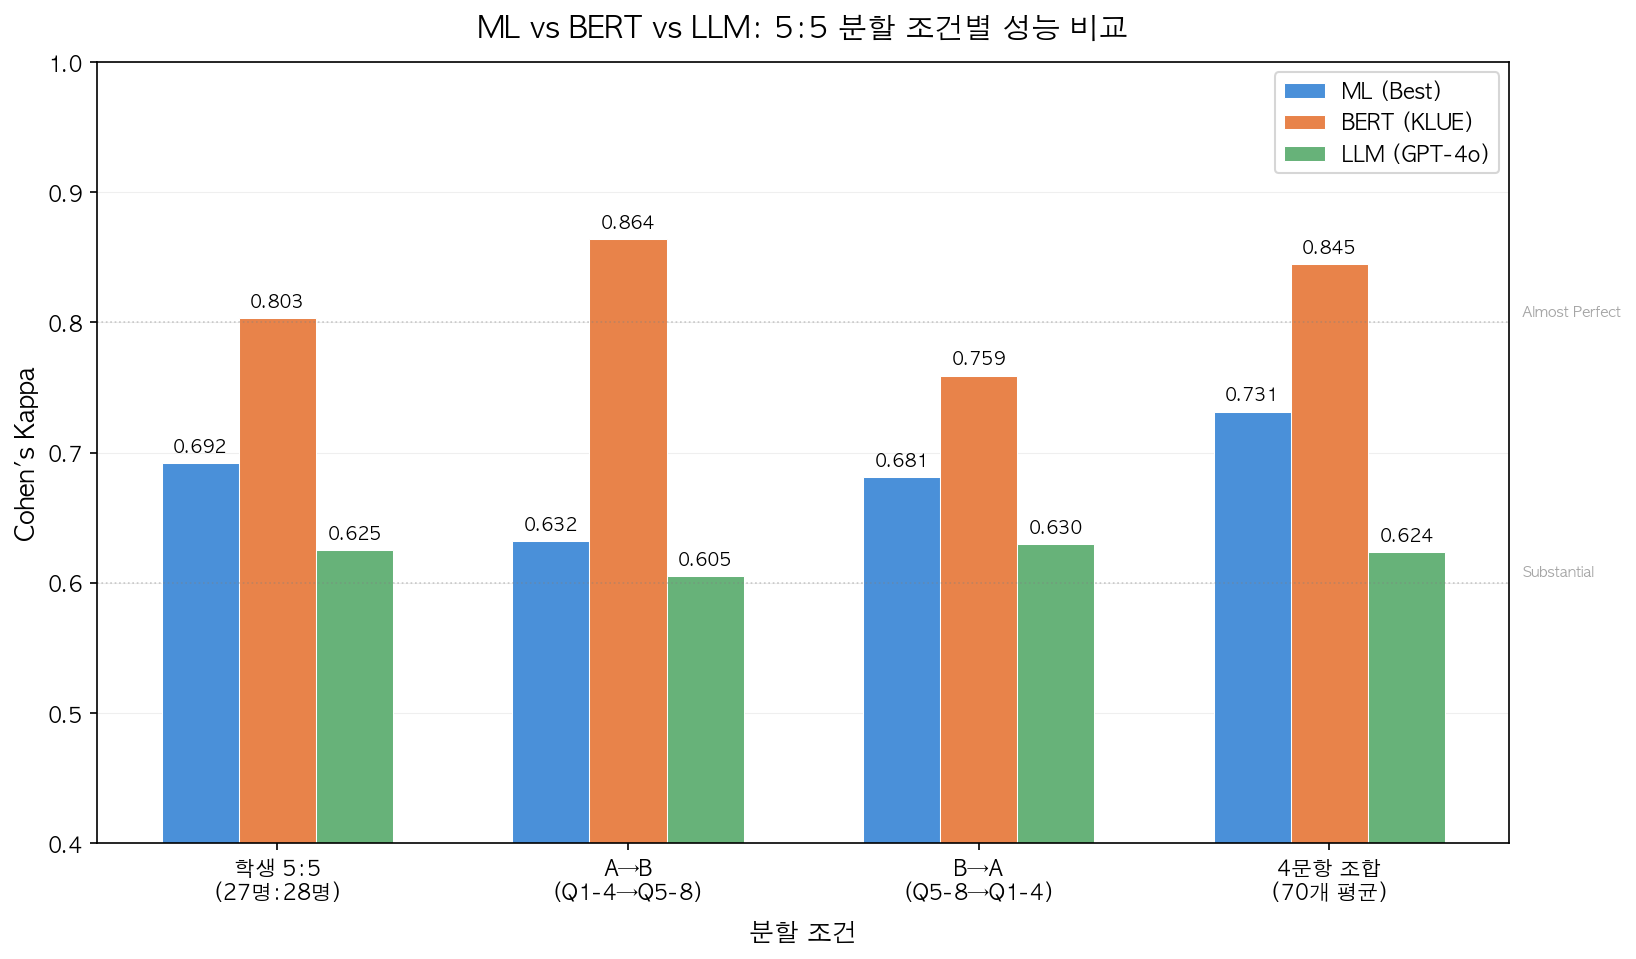

그래프 저장 완료: comparison_5050_split.png


In [15]:
# ============================================================
# 비교 그래프 생성
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6.5))

# --- 그래프 데이터 ---
# x축 라벨 (줄바꿈 포함으로 가독성 확보)
conditions = [
    '학생 5:5\n(27명:28명)',
    'A→B\n(Q1-4→Q5-8)',
    'B→A\n(Q5-8→Q1-4)',
    '4문항 조합\n(70개 평균)'
]
x = np.arange(len(conditions))
width = 0.22  # 막대 너비 (3개 막대가 겹치지 않도록 조정)

# --- 색상 설정 ---
# 수정하려면 아래 hex 코드를 변경하세요
colors = {
    'ML':   '#4A90D9',   # 파란색 계열
    'BERT': '#E8834A',   # 주황색 계열
    'LLM':  '#67B279'    # 초록색 계열
}

# --- 막대 그래프 ---
vals_ml   = results['ML'].values
vals_bert = results['BERT'].values
vals_llm  = results['LLM'].values

bars_ml   = ax.bar(x - width, vals_ml,   width, label='ML (Best)',
                    color=colors['ML'],   edgecolor='white', linewidth=0.5)
bars_bert = ax.bar(x,         vals_bert,  width, label='BERT (KLUE)',
                    color=colors['BERT'], edgecolor='white', linewidth=0.5)
bars_llm  = ax.bar(x + width, vals_llm,  width, label='LLM (GPT-4o)',
                    color=colors['LLM'],  edgecolor='white', linewidth=0.5)

# --- 막대 위 값 표시 ---
for bars in [bars_ml, bars_bert, bars_llm]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f'{h:.3f}',
            xy=(bar.get_x() + bar.get_width() / 2, h),
            xytext=(0, 4),
            textcoords='offset points',
            ha='center', va='bottom',
            fontsize=8.5, fontweight='bold'
        )

# --- 축 및 제목 설정 ---
ax.set_xlabel('분할 조건', fontsize=12, fontweight='bold', labelpad=8)
ax.set_ylabel("Cohen's Kappa", fontsize=12, fontweight='bold')
ax.set_title('ML vs BERT vs LLM: 5:5 분할 조건별 성능 비교',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=10)
ax.legend(fontsize=10, loc='upper right')

# --- y축 범위 ---
# 차이를 명확히 보기 위해 0.4~1.0 범위로 설정
# 전체 범위(0~1)를 원하면 아래 줄을 수정하세요
ax.set_ylim(0.4, 1.0)

# --- 기준선 (Kappa 해석 기준) ---
ax.axhline(y=0.6, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
ax.axhline(y=0.8, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
ax.text(3.55, 0.605, 'Substantial', fontsize=7, color='gray', alpha=0.7)
ax.text(3.55, 0.805, 'Almost Perfect', fontsize=7, color='gray', alpha=0.7)

# --- 그리드 ---
ax.grid(axis='y', alpha=0.2, linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()

# --- 저장 ---
# 저장 경로/형식을 변경하려면 아래를 수정하세요
save_path = 'comparison_5050_split.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f'그래프 저장 완료: {save_path}')

**결과 해석:**

이 막대 차트는 RQ2(일반화)에 대한 핵심 답변을 제공합니다.

- **BERT가 모든 조건에서 최고 성능**: 학생 5:5(0.803), A->B(0.864), B->A(0.759), 4문항 평균(0.845)으로 일관되게 "almost perfect" 또는 "substantial" 수준 유지
- **ML은 조건에 따라 변동**: A->B(0.632)에서 B->A(0.681)보다 낮은 성능을 보여, ML이 문항 방향에 민감함
- **LLM은 안정적이나 낮은 성능**: 모든 조건에서 0.60~0.63으로 학습 조건에 무관한 안정적 성능이지만, 학습 기반 접근법에 미치지 못함
- **시사점**: BERT는 새로운 학생이나 문항으로의 일반화에서도 뛰어난 강건성(robustness)을 보이며, LLM은 학습 데이터 없이도 일정 수준의 분류가 가능하나 한계가 있음

## 결과 시각화: 조건별 비교 막대 차트

그룹 막대 차트(Grouped Bar Chart)로 4가지 분할 조건에서의 ML, BERT, LLM 성능을 한눈에 비교합니다. y축의 점선은 Kappa 해석 기준(Substantial=0.6, Almost Perfect=0.8)을 나타냅니다.

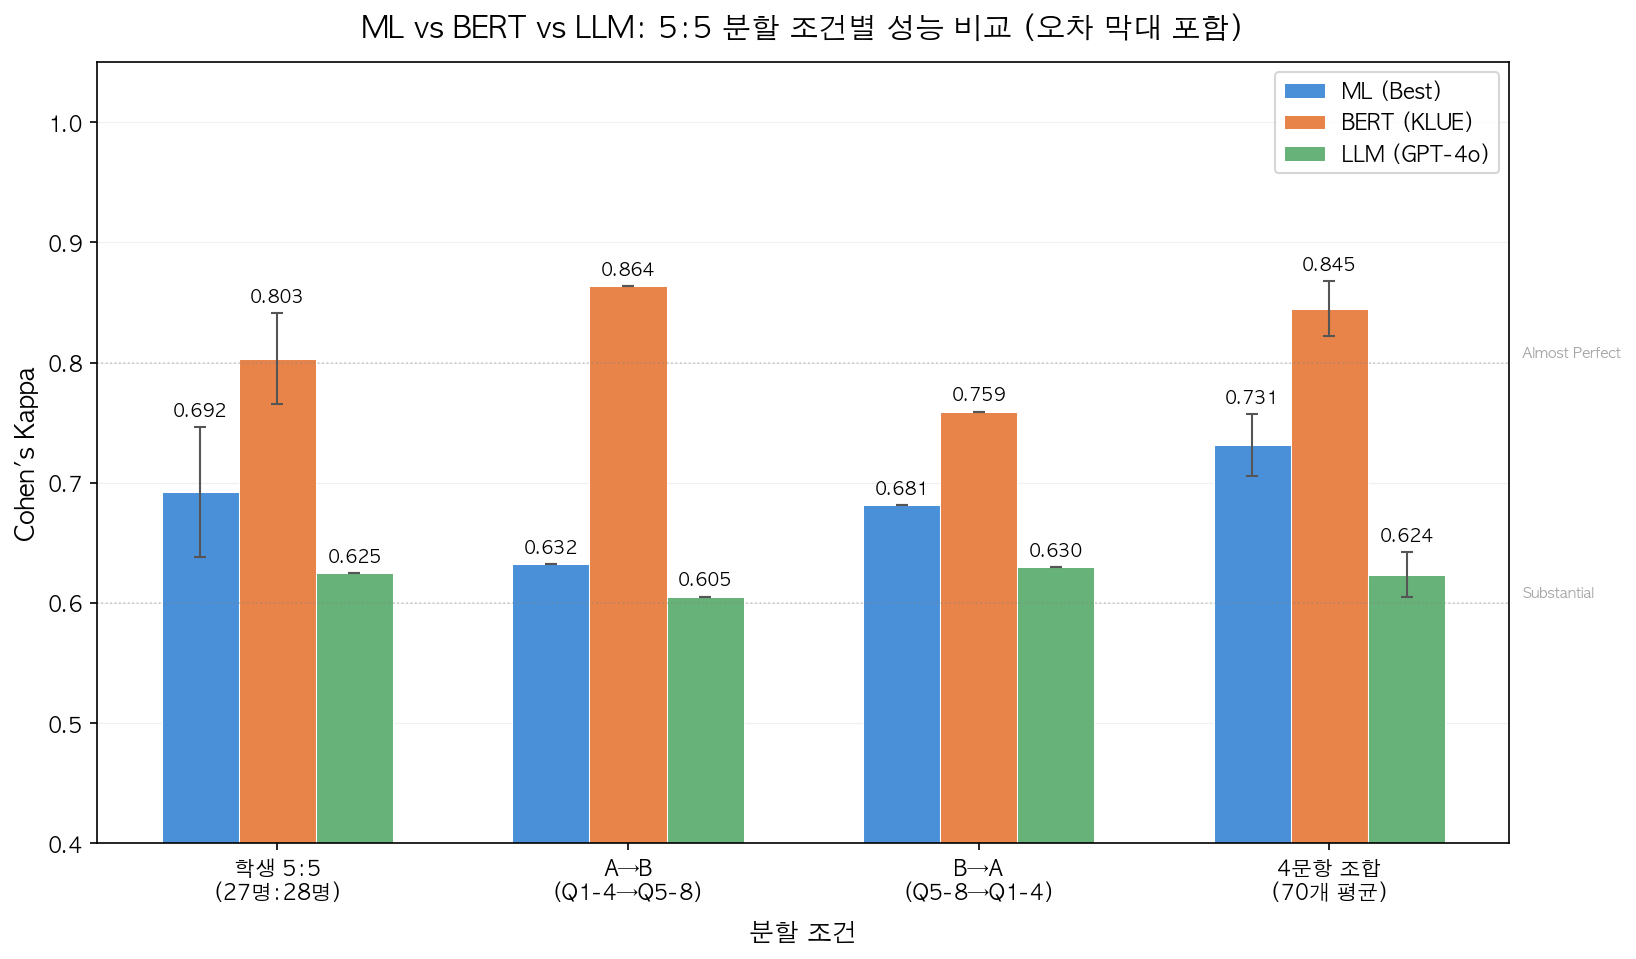

그래프 저장 완료: comparison_5050_split_with_error.png


In [16]:
# ============================================================
# (선택) 오차 막대 포함 그래프
# - 학생 분할: seed 간 표준편차
# - 4문항 조합: 70개 조합 간 표준편차
# - A→B, B→A: 단일 값이므로 오차 없음
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6.5))

# 오차 데이터 (0 = 오차 없음)
err_ml   = [ml_std_student,   0, 0, ml_std_4q]
err_bert = [bert_std_student, 0, 0, bert_std_4q]
err_llm  = [0,                0, 0, llm_std_4q]

conditions = [
    '학생 5:5\n(27명:28명)',
    'A→B\n(Q1-4→Q5-8)',
    'B→A\n(Q5-8→Q1-4)',
    '4문항 조합\n(70개 평균)'
]
x = np.arange(len(conditions))
width = 0.22

# 오차 막대 스타일
err_kw = dict(capsize=3, capthick=1, elinewidth=1, ecolor='#555555')

bars_ml   = ax.bar(x - width, vals_ml,   width, yerr=err_ml,
                    label='ML (Best)',    color=colors['ML'],   edgecolor='white',
                    linewidth=0.5, error_kw=err_kw)
bars_bert = ax.bar(x,         vals_bert,  width, yerr=err_bert,
                    label='BERT (KLUE)',  color=colors['BERT'], edgecolor='white',
                    linewidth=0.5, error_kw=err_kw)
bars_llm  = ax.bar(x + width, vals_llm,  width, yerr=err_llm,
                    label='LLM (GPT-4o)', color=colors['LLM'],  edgecolor='white',
                    linewidth=0.5, error_kw=err_kw)

# 막대 위 값 표시
for bars, errs in zip([bars_ml, bars_bert, bars_llm], [err_ml, err_bert, err_llm]):
    for bar, e in zip(bars, errs):
        h = bar.get_height()
        offset = e + 0.008 if e > 0 else 0.005
        ax.annotate(
            f'{h:.3f}',
            xy=(bar.get_x() + bar.get_width() / 2, h + e),
            xytext=(0, 4),
            textcoords='offset points',
            ha='center', va='bottom',
            fontsize=8.5, fontweight='bold'
        )

ax.set_xlabel('분할 조건', fontsize=12, fontweight='bold', labelpad=8)
ax.set_ylabel("Cohen's Kappa", fontsize=12, fontweight='bold')
ax.set_title('ML vs BERT vs LLM: 5:5 분할 조건별 성능 비교 (오차 막대 포함)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=10)
ax.legend(fontsize=10, loc='upper right')
ax.set_ylim(0.4, 1.05)

ax.axhline(y=0.6, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
ax.axhline(y=0.8, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
ax.text(3.55, 0.605, 'Substantial', fontsize=7, color='gray', alpha=0.7)
ax.text(3.55, 0.805, 'Almost Perfect', fontsize=7, color='gray', alpha=0.7)

ax.grid(axis='y', alpha=0.2, linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
save_path2 = 'comparison_5050_split_with_error.png'
plt.savefig(save_path2, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f'그래프 저장 완료: {save_path2}')

=== ML 전체 모델 평균 (24개 모델) ===
  학생 5:5:    0.6152 (±0.0438)
  A→B:         0.5614 (±0.0369)
  B→A:         0.6393 (±0.0290)
  4문항 조합:  0.6726 (±0.0216)


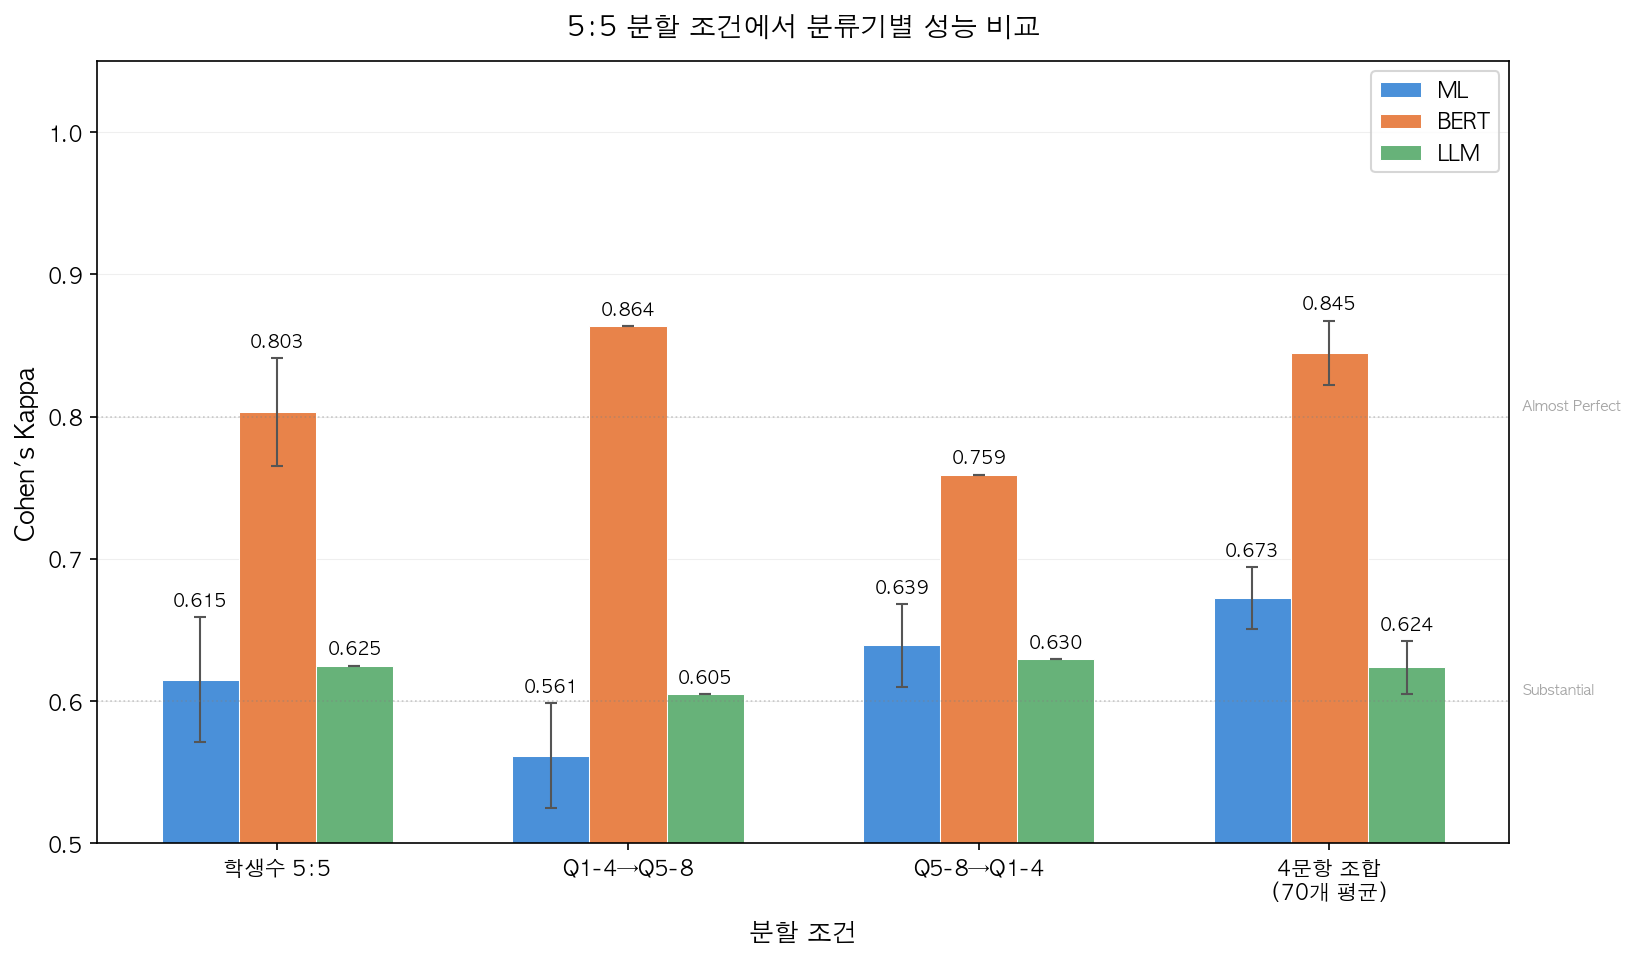

그래프 저장 완료: comparison_5050_ml_all_models.png


In [18]:
# ============================================================
# ML 전체 모델 평균 기반 비교 그래프
# - ML: 24개 모델(개별 9 + 앙상블 15) 전체 평균 ± 모델 간 std
# - BERT: 단일 모델(KLUE-BERT), seed 또는 조합에 따른 변동만 존재
# - LLM: 단일 모델(GPT-4o), 조합에 따른 변동만 존재
#
# 오차 막대 의미:
#   ML      → 24개 모델 간 성능 편차 (모델 선택의 영향)
#   BERT    → 학생5:5는 seed 편차, 4문항은 조합 편차
#   LLM     → 4문항은 조합 편차, 나머지는 단일 값(오차 없음)
# ============================================================

# ---- ML: 전체 모델 평균 재계산 ----

# 학생 5:5: 각 모델의 3-seed 평균 → 24개 모델의 grand mean
ml_model_means_ss = ml_ss_50.groupby('Model')['Test_Kappa'].mean()
ml_avg_student = ml_model_means_ss.mean()
ml_avg_std_student = ml_model_means_ss.std()

# A→B: 24개 모델의 평균/std
ml_ab_all = ml_question[ml_question['Combo'] == 'Q1_Q2_Q3_Q4']
ml_avg_ab = ml_ab_all['Test_Kappa'].mean()
ml_avg_std_ab = ml_ab_all['Test_Kappa'].std()

# B→A: 24개 모델의 평균/std
ml_ba_all = ml_question[ml_question['Combo'] == 'Q5_Q6_Q7_Q8']
ml_avg_ba = ml_ba_all['Test_Kappa'].mean()
ml_avg_std_ba = ml_ba_all['Test_Kappa'].std()

# 4문항 조합: 각 조합별 24모델 평균 → 70개 조합의 grand mean
ml_combo_means_4q = ml_4q.groupby('Combo')['Test_Kappa'].mean()
ml_avg_4q = ml_combo_means_4q.mean()
ml_avg_std_4q = ml_combo_means_4q.std()

print('=== ML 전체 모델 평균 (24개 모델) ===')
print(f'  학생 5:5:    {ml_avg_student:.4f} (±{ml_avg_std_student:.4f})')
print(f'  A→B:         {ml_avg_ab:.4f} (±{ml_avg_std_ab:.4f})')
print(f'  B→A:         {ml_avg_ba:.4f} (±{ml_avg_std_ba:.4f})')
print(f'  4문항 조합:  {ml_avg_4q:.4f} (±{ml_avg_std_4q:.4f})')

# ---- 그래프 데이터 구성 ----
vals_ml_avg   = [ml_avg_student,    ml_avg_ab,       ml_avg_ba,       ml_avg_4q]
vals_bert_avg = [bert_kappa_student, bert_kappa_ab,   bert_kappa_ba,   bert_kappa_4q_avg]
vals_llm_avg  = [llm_kappa_student,  llm_kappa_ab,    llm_kappa_ba,    llm_kappa_4q_avg]

# 오차 막대: 변동 원인이 있는 경우만 표시
err_ml_avg   = [ml_avg_std_student,  ml_avg_std_ab,   ml_avg_std_ba,   ml_avg_std_4q]
err_bert_avg = [bert_std_student,    0,               0,               bert_std_4q]
err_llm_avg  = [0,                   0,               0,               llm_std_4q]

# ---- 그래프 생성 ----
fig, ax = plt.subplots(figsize=(11, 6.5))

conditions = [
    '학생수 5:5',
    'Q1-4→Q5-8',
    'Q5-8→Q1-4',
    '4문항 조합\n(70개 평균)'
]
x = np.arange(len(conditions))
width = 0.22

err_kw = dict(capsize=3, capthick=1, elinewidth=1, ecolor='#555555')

bars_ml = ax.bar(x - width, vals_ml_avg,   width, yerr=err_ml_avg,
                 label='ML', color=colors['ML'],   edgecolor='white',
                 linewidth=0.5, error_kw=err_kw)
bars_bert = ax.bar(x,       vals_bert_avg, width, yerr=err_bert_avg,
                 label='BERT',      color=colors['BERT'], edgecolor='white',
                 linewidth=0.5, error_kw=err_kw)
bars_llm = ax.bar(x + width, vals_llm_avg, width, yerr=err_llm_avg,
                 label='LLM',     color=colors['LLM'],  edgecolor='white',
                 linewidth=0.5, error_kw=err_kw)

# 막대 위 값 표시
for bars, errs in zip([bars_ml, bars_bert, bars_llm],
                      [err_ml_avg, err_bert_avg, err_llm_avg]):
    for bar, e in zip(bars, errs):
        h = bar.get_height()
        ax.annotate(
            f'{h:.3f}',
            xy=(bar.get_x() + bar.get_width() / 2, h + e),
            xytext=(0, 4),
            textcoords='offset points',
            ha='center', va='bottom',
            fontsize=8.5, fontweight='bold'
        )

ax.set_xlabel('분할 조건', fontsize=12, fontweight='bold', labelpad=8)
ax.set_ylabel("Cohen's Kappa", fontsize=12, fontweight='bold')
ax.set_title('5:5 분할 조건에서 분류기별 성능 비교',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=10)
ax.legend(fontsize=10, loc='upper right')
ax.set_ylim(0.5, 1.05)

ax.axhline(y=0.6, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
ax.axhline(y=0.8, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
ax.text(3.55, 0.605, 'Substantial', fontsize=7, color='gray', alpha=0.7)
ax.text(3.55, 0.805, 'Almost Perfect', fontsize=7, color='gray', alpha=0.7)

ax.grid(axis='y', alpha=0.2, linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
save_path3 = 'comparison_5050_ml_all_models.png'
plt.savefig(save_path3, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f'그래프 저장 완료: {save_path3}')